In [1]:
import requests
res = requests.get("https://ark.cn-beijing.volces.com", timeout=10, proxies=None)
print(res.status_code)

401


In [2]:
import requests

# 导入配置文件放最顶部
try:
    from config import API_KEY, ARK_URL as url, MODEL_NAME
except ImportError:
    raise SystemExit("找不到config.py文件！复制config_template.py，重命名为config.py，填入你的密钥")

headers = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {API_KEY}"
}
payload = {
    "model": MODEL_NAME,
    "messages": [
        {"role": "user", "content": "你好，写一段简单Python代码打印1到10"}
    ]
}

# 分层捕获接口异常
try:
    # 删除无用 proxies=None
    res = requests.post(url, headers=headers, json=payload, timeout=15)
    print("状态码：", res.status_code)
    res_json = res.json()
    print("完整返回json：", res_json)
    
    # 打印token消耗
    token_usage = res_json["usage"]
    print(f"Token消耗：输入{token_usage['prompt_tokens']}，输出{token_usage['completion_tokens']}")
    
    raw_text = res_json["choices"][0]["message"]["content"]
    print("\n模型原始输出内容：\n", raw_text)
    
    # 正则提取纯代码，兼容空格
    import re
    code_blocks = re.findall(r'```\s*python\s*(.*?)\s*```', raw_text, re.DOTALL)
    if code_blocks:
        pure_code = "\n".join([c.strip() for c in code_blocks])
    else:
        pure_code = raw_text
    pure_code = "\n".join([line.strip() for line in pure_code.splitlines() if line.strip()])
    print("\n提取后的可运行代码：\n", pure_code)

except Exception as e:
    print("接口报错信息：", e)

状态码： 200
完整返回json： {'choices': [{'finish_reason': 'stop', 'index': 0, 'logprobs': None, 'message': {'content': '你可以使用 `for` 循环配合 `range()` 函数来实现，代码如下：\n\n\n```python\n# 打印1到10（包含10）\nfor i in range(1, 11):\n    print(i)\n```\n\n\n### 说明：\n- `range(1, 11)` 会生成从 **1 到 10** 的整数序列（因为 Python 的 `range` 是“左闭右开”区间，所以结束值要写 11 才能包含 10）；\n- 循环中每次把序列里的数赋值给 `i`，然后用 `print(i)` 打印出来。', 'reasoning_content': '\n用户现在需要一段简单的Python代码打印1到10。首先，我得想最直接的方法，比如用for循环，range函数的话，range(1,11)因为是左闭右开，所以到11才能包含10。然后循环里打印每个数。或者也可以用while，但for更简单。那先写个for循环的版本吧，应该最直观。然后解释一下代码，让用户明白为什么range是1到11。嗯，就这样，代码要简单，解释清楚。', 'role': 'assistant'}}], 'created': 1783167723, 'id': '02178316771773944a0c29b4a29aed28235da222addf5f1f42681', 'model': 'doubao-seed-2-0-code-preview-260215', 'service_tier': 'default', 'object': 'chat.completion', 'usage': {'completion_tokens': 263, 'prompt_tokens': 43, 'total_tokens': 306, 'prompt_tokens_details': {'cached_tokens': 0}, 'completion_tokens_details': {'reasoning_tokens': 117}}}
Token消耗：输入43，输出263

In [5]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import requests

from config import API_KEY, ARK_URL as url, MODEL_NAME

# 解决中文绘图乱码，多字体兼容
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei", "PingFang SC", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

# 读取数据集
try:
    df = pd.read_csv("sales_data.csv")
    print("数据集加载成功，字段：", df.columns.tolist())
except FileNotFoundError:
    print("错误：sales_data.csv 文件不存在，请放到代码同目录下")
    df = None
except Exception as e:
    print("数据集读取失败：", e)
    df = None

def data_analysis_agent(question, df):
    prompt = f"""
你是专业数据分析助手，现有零售数据集df，字段列表：{df.columns.tolist()}
强制规则：
1. 只输出可直接运行的纯Python代码，禁止输出任何中文、解释、注释、Markdown、```代码块标记；
2. 统计结果必须使用print()打印输出；
3. 绘图代码末尾必须写plt.show();
4. 不要添加多余import，上下文已导入pd、plt。
用户需求：{question}
    """
    
    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {API_KEY}"
    }
    payload = {
        "model": MODEL_NAME,
        "messages": [{"role": "user", "content": prompt}]
    }

    # 第一层：仅捕获网络、鉴权、接口报错
    try:
        response = requests.post(
            url,
            headers=headers,
            json=payload,
            timeout=20
        )
        response.raise_for_status()
        result = response.json()
        raw_text = result["choices"][0]["message"]["content"]
        # 打印token消耗，项目加分
        token_usage = result["usage"]
        print(f"Token消耗：输入{token_usage['prompt_tokens']}，输出{token_usage['completion_tokens']}")
    except Exception as api_err:
        print(f"【接口请求异常】{api_err}")
        return ""

    # 第二层：单独捕获正则提取代码报错
    try:
        # 优化正则，兼容前后空格的python代码块
        code_blocks = re.findall(r'```\s*python\s*(.*?)\s*```', raw_text, re.DOTALL)
        if code_blocks:
            generate_code = "\n".join([block.strip() for block in code_blocks])
        else:
            generate_code = raw_text
        # 清除多余空行
        generate_code = "\n".join([line.strip() for line in generate_code.splitlines() if line.strip()])
    except Exception as re_err:
        print(f"【代码提取清洗失败】{re_err}")
        generate_code = raw_text

    print("====模型自动生成代码====\n", generate_code)

    # 第三层：单独捕获AI代码运行报错
    try:
        exec(generate_code, {"df": df, "pd": pd, "plt": plt})
    except Exception as code_err:
        print(f"【AI代码执行出错】{code_err}")
    
    # 返回生成的代码，方便外部保存使用
    return generate_code


# 执行分析任务，增加df非空判断，防止df=None报错
if df is not None:
    data_analysis_agent("帮我统计每个品类的总销售额，从高到低排序", df)
else:
    print("数据集加载失败，无法执行数据分析任务")

数据集加载成功，字段： ['InvoiceNo', 'StockCode', 'Quantity', 'UnitPrice', 'Total', 'InvoiceDate', 'Category', 'Month', 'UserID']
Token消耗：输入173，输出130
====模型自动生成代码====
 category_sales = df.groupby('Category')['Total'].sum().sort_values(ascending=False).reset_index()
print(category_sales)
  Category      Total
0       服饰  113709.16
1      日用品  104944.07
2       零食  103416.84
3       数码  103119.57
4       家居  100485.29


【增强版程序】数据集加载成功
【增强版程序】字段列表： ['InvoiceNo', 'StockCode', 'Quantity', 'UnitPrice', 'Total', 'InvoiceDate', 'Category', 'Month', 'UserID']

===== 新分析任务：统计每个品类总销售额从高到低排序，打印表格并绘制横向柱状图 =====
Token消耗：输入155，输出691
【AI生成可执行代码】
 category_sales = df.groupby('Category')['Total'].sum().sort_values(ascending=False)
print(category_sales.reset_index())
plt.barh(category_sales.index, category_sales.values)
plt.xlabel('Total Sales')
plt.ylabel('Category')
plt.title('Total Sales by Category (Descending)')
plt.gca().invert_yaxis()
plt.show()
  Category      Total
0       服饰  113709.16
1      日用品  104944.07
2       零食  103416.84
3       数码  103119.57
4       家居  100485.29


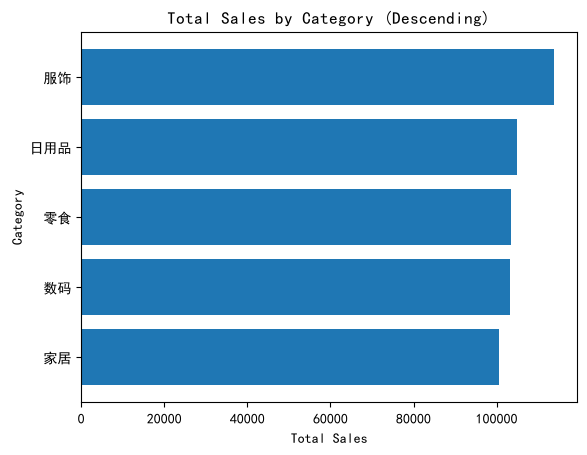

✅ 任务执行成功

全部任务完成，完整运行日志保存至：数据分析完整日志_20260704_202501.txt


In [6]:
import re
import time
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import requests

try:
    from config import API_KEY, ARK_URL as url, MODEL_NAME
except ImportError:
    raise SystemExit("缺失config.py配置文件，请创建并填入密钥、接口、模型名称")

# ===================== 独立全局配置（和你原有代码隔离，互不影响） =====================
# 多字体兜底，解决全平台中文乱码
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

# 本次运行专属日志文件
log_time = datetime.now().strftime("%Y%m%d_%H%M%S")
log_file = f"数据分析完整日志_{log_time}.txt"

# ===================== 独立数据集加载（读取同一份csv，不覆盖原有df） =====================
try:
    df_full = pd.read_csv("sales_data.csv")
    print("【增强版程序】数据集加载成功")
    print("【增强版程序】字段列表：", df_full.columns.tolist())
    # 初始化日志文件
    with open(log_file, "w", encoding="utf-8") as f:
        f.write(f"程序启动时间：{datetime.now()}\n数据集字段：{df_full.columns.tolist()}\n\n")
except Exception as load_err:
    print("【增强版程序】csv文件读取失败：", load_err)
    raise SystemExit("终止运行，缺少sales_data.csv")

# ===================== 增强版AI分析函数（全套容错清洗流程） =====================
def full_auto_analysis(question: str):
    print(f"\n===== 新分析任务：{question} =====")
    # 写入日志
    with open(log_file, "a", encoding="utf-8") as f:
        f.write(f"任务需求：{question}\n")

    # 强限制prompt，杜绝模型输出多余文字
    prompt = f"""
现有零售数据集df，字段：{df_full.columns.tolist()}，可使用pd、plt，无需重复导入库。
硬性规则：
1. 只输出可执行纯Python代码，禁止中文、注释、markdown、```标记；
2. 统计结果必须print打印；
3. 绘图代码末尾必须写plt.show()；
用户需求：{question}
    """

    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {API_KEY}"
    }
    payload = {
        "model": MODEL_NAME,
        "messages": [{"role": "user", "content": prompt}]
    }

    # 第一层：捕获接口、网络、鉴权类错误
    try:
        # 修复：把ARK_URL改为url，删除冗余proxies=None
        resp = requests.post(url, headers=headers, json=payload, timeout=20)
        resp.raise_for_status()
        res_json = resp.json()
        raw_reply = res_json["choices"][0]["message"]["content"]
        
        # 打印token消耗，项目简历加分
        token_usage = res_json["usage"]
        print(f"Token消耗：输入{token_usage['prompt_tokens']}，输出{token_usage['completion_tokens']}")

        # 深度清洗：优化正则，兼容代码块前后空格
        code_match = re.findall(r'```\s*python\s*(.*?)\s*```', raw_reply, re.DOTALL)
        if code_match:
            pure_code = "\n".join([c.strip() for c in code_match])
        else:
            pure_code = raw_reply
        # 清除空行
        pure_code = "\n".join([line.strip() for line in pure_code.splitlines() if line.strip()])

        print("【AI生成可执行代码】\n", pure_code)
        # 日志保存生成代码
        with open(log_file, "a", encoding="utf-8") as f:
            f.write(f"生成代码：\n{pure_code}\n")

        # 第二层：单独捕获代码运行报错，和接口错误分开
        try:
            exec(pure_code, {"df": df_full, "pd": pd, "plt": plt})
            print("✅ 任务执行成功")
            with open(log_file, "a", encoding="utf-8") as f:
                f.write("执行状态：成功\n\n")
        except Exception as code_error:
            print("❌ AI代码运行报错：", code_error)
            with open(log_file, "a", encoding="utf-8") as f:
                f.write(f"执行状态：失败，报错：{code_error}\n\n")

    except Exception as api_error:
        print("❌ 方舟接口调用失败：", api_error)
        with open(log_file, "a", encoding="utf-8") as f:
            f.write(f"接口调用失败，报错：{api_error}\n\n")
    # 请求间隔，防止风控限流
    time.sleep(1)
    # 返回生成代码，外部可保存复用
    return pure_code

# ===================== 任务执行入口（单任务/批量任务二选一） =====================
if __name__ == "__main__":
    # 1. 单次执行示例（直接运行这个）
    full_auto_analysis("统计每个品类总销售额从高到低排序，打印表格并绘制横向柱状图")

    # 2. 批量多任务（取消注释即可批量执行多个需求）
    """
    task_list = [
        "统计每个品类总销售额从高到低排序，打印表格并绘制横向柱状图",
        "按月汇总销售总额，绘制月度销售额折线图",
        "筛选销量最高的5个商品并打印",
        "计算各品类平均单品售价并降序展示"
    ]
    for task in task_list:
        full_auto_analysis(task)
    """

    print(f"\n全部任务完成，完整运行日志保存至：{log_file}")